## MALL Cleaning

**Purpose:** The purpose of this notebook is to generate the MALL dataframe by adding additional features to the MHAR feature set. 

In [180]:
import pandas as pd
import numpy as np
import os

# Load MHAR dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data Sets/MHAR.csv"
MHAR = pd.read_csv(file_path, index_col="Date", parse_dates=True)

# Verify
print(f"Shape: {MHAR.shape}")
print(f"Index type: {type(MHAR.index)}")
print(f"Index dtype: {MHAR.index.dtype}")
print(f"Date range: {MHAR.index[0].strftime('%Y-%m-%d')} to {MHAR.index[-1].strftime('%Y-%m-%d')}")
print(f"NaN values: {MHAR.isna().sum().sum()}")
print(f"\nFirst few rows:")
MHAR.head()

Shape: (5673, 12)
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index dtype: datetime64[ns]
Date range: 1998-03-31 to 2020-08-07
NaN values: 0

First few rows:


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,RM_neg,RQ
Date,,,,,,,,,,,,
1998-03-31,0.000054,0.000110,0.000090,-9.821033,-9.114256,-9.316358,0.000028,0.000026,0.0,-0.002720,-0.002111,4.659943e-09
1998-04-01,0.000078,0.000112,0.000089,-9.460937,-9.097026,-9.329180,0.000043,0.000034,0.0,-0.002720,-0.002111,8.577656e-09
1998-04-02,0.000078,0.000114,0.000087,-9.454030,-9.075029,-9.355285,0.000046,0.000033,0.0,-0.002720,-0.002111,1.707249e-08
1998-04-03,0.000113,0.000078,0.000089,-9.088575,-9.454753,-9.327895,0.000066,0.000047,0.0,-0.000894,-0.001792,3.407098e-08
1998-04-06,0.000093,0.000083,0.000089,-9.286574,-9.393992,-9.328772,0.000074,0.000019,0.0,0.000000,-0.001276,3.205750e-08


### 1. Adding Variables to Create MALL data set

In [183]:
# Merge VSTOXX with MHAR using a left join to preserve MHAR trading days
MALL = MHAR.copy()

#### 1.1 VSTOXX index

In [186]:
# Load VSTOXX data
vstoxx_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/M-ALL Feature Set/VSTOXX.csv"
VSTOXX = pd.read_csv(vstoxx_path)

# Drop Symbol column as it is constant and uninformative
VSTOXX = VSTOXX.drop(columns=["Symbol"])

# Convert Date to DatetimeIndex
VSTOXX["Date"] = pd.to_datetime(VSTOXX["Date"])
VSTOXX = VSTOXX.set_index("Date")

# Rename column to uppercase for consistency with MHAR naming convention
VSTOXX = VSTOXX.rename(columns={"vstoxx": "VSTOXX"})

# Merge VSTOXX with MALL using a left join to preserve MHAR trading days
MALL = MHAR.copy()
MALL = MALL.join(VSTOXX, how="left")

# Forward fill the 22 mid-sample NaN values (Christmas Eve, New Year's Eve, Labour Day etc.)
MALL["VSTOXX"] = MALL["VSTOXX"].ffill()

# Add log VSTOXX for use in LogHAR-X model
MALL["logVSTOXX"] = np.log(MALL["VSTOXX"])

#### 1.2 EPU index 

In [189]:
# Load EPU data
epu_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/M-ALL Feature Set/EPU.xlsx"
EPU = pd.read_excel(epu_path)

# Drop the last row which is a source citation
EPU = EPU.dropna(subset=["Month"])

# Keep only European News Index
EPU = EPU[["Year", "Month", "European_News_Index"]].copy()

# Convert Year and Month to integer
EPU["Year"]  = EPU["Year"].astype(int)
EPU["Month"] = EPU["Month"].astype(int)

# Construct a proper date from Year and Month
EPU["Date"] = pd.to_datetime(
    EPU["Year"].astype(str) + "-" + EPU["Month"].astype(str) + "-01"
)
EPU = EPU.set_index("Date")
EPU = EPU.drop(columns=["Year", "Month"])
EPU = EPU.rename(columns={"European_News_Index": "EPU"})

# Merge EPU with MALL using a left join
MALL = MALL.join(EPU, how="left")

# Forward fill EPU across trading days within each month
MALL["EPU"] = MALL["EPU"].ffill()

# Add log EPU
MALL["logEPU"] = np.log(MALL["EPU"])

# Create one-month lagged EPU using resample to ensure correct monthly alignment
MALL["EPU_1m_lag"] = (
    MALL["EPU"]
    .resample("MS")
    .first()
    .shift(1)
    .reindex(MALL.index, method="ffill")
)

# Add log lagged EPU
MALL["logEPU_1m_lag"] = np.log(MALL["EPU_1m_lag"])

### 1.3 EUR/USD Exchange rate 

**Source:** Retrieved from ECB's website

In [193]:
# Load EUR/USD exchange rate data from ECB
eurusd_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/M-ALL Feature Set/ECB Data Portal long_20260311191107.xlsx"
EURUSD = pd.read_excel(eurusd_path, sheet_name="DATA(EXR)")

# Keep only DATE and OBS.VALUE columns
EURUSD = EURUSD[["DATE", "OBS.VALUE"]].copy()

# Convert DATE to DatetimeIndex and rename OBS.VALUE
EURUSD["DATE"] = pd.to_datetime(EURUSD["DATE"])
EURUSD = EURUSD.set_index("DATE")
EURUSD = EURUSD.rename(columns={"OBS.VALUE": "EURUSD"})

# Forward fill weekend and holiday NaN values
EURUSD["EURUSD"] = EURUSD["EURUSD"].ffill()

# Merge with MALL using a left join
MALL = MALL.join(EURUSD, how="left")

# Add daily log return of EURUSD
MALL["EURUSD_ret"] = np.log(MALL["EURUSD"] / MALL["EURUSD"].shift(1))

### 1.4 CISS

**Source:** Retrieved from ECB's website

In [197]:
# Load CISS data
ciss_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/M-ALL Feature Set/CISS.csv"
CISS = pd.read_csv(ciss_path)

# Rename the long column name for easier reference
CISS = CISS.rename(columns={
    "NEW CISS - Composite Indicator of Systemic Stress. (CISS.D.U2.Z0Z.4F.EC.SS_CIN.IDX)": "CISS"
})

# Drop TIME PERIOD column
CISS = CISS.drop(columns=["TIME PERIOD"])

# Convert DATE to DatetimeIndex
CISS["DATE"] = pd.to_datetime(CISS["DATE"])
CISS = CISS.set_index("DATE")

# Merge with MALL using a left join
MALL = MALL.join(CISS, how="left")

### 1.5 Europe Brent Crude Oil Spot Price

**Source:** U.S. Energy information Administration (EIA)

Rationale for including Europe Brent Crude Oil Price: 

**1. Energy sector weight**
The EURO STOXX 50 has a significant allocation to energy companies such as TotalEnergies, Shell, and Eni. Oil price movements directly affect earnings expectations and therefore equity volatility for these constituents in a way that is less relevant for the diversified DJIA.

**2. European macroeconomic sensitivity**
Europe is a net energy importer, meaning oil price shocks have a more direct and immediate pass-through to European economic conditions compared to the US which is now a net energy exporter. This makes Brent particularly relevant for a European equity index.

**3. Established literature support**
There is a well-established body of literature documenting the relationship between oil price volatility and equity market volatility, particularly for European markets. Papers by Malik and Hammoudeh (2007) and Degiannakis, Filis and Arora (2018) specifically document this relationship for European indices.

**4. Crisis period relevance**
Sample includes the 2008 oil price spike to $147 and the 2020 oil price crash to negative territory — both of which coincided with extreme equity market volatility. Including Brent captures this channel explicitly.

Unlike Christensen et al. (2023) who focus on DJIA constituents in the US market, our European focus motivates the inclusion of Brent crude oil prices as an additional predictor, given Europe's status as a net energy importer and the significant energy sector weight in the EURO STOXX 50.

In [201]:
# Load Brent crude oil price data skipping 4 metadata rows
brent_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/M-ALL Feature Set/Europe_Brent_Spot_Price_FOB.csv"
BRENT = pd.read_csv(brent_path, skiprows=4)

# Rename columns
BRENT.columns = ["Date", "BRENT"]

# Convert Date to DatetimeIndex
BRENT["Date"] = pd.to_datetime(BRENT["Date"])
BRENT = BRENT.set_index("Date")

# Sort ascending since EIA data comes in reverse chronological order
BRENT = BRENT.sort_index()

# Merge BRENT with MALL using a left join
MALL = MALL.join(BRENT, how="left")

# Forward fill any NaN values from weekends/holidays
MALL["BRENT"] = MALL["BRENT"].ffill()

# Add daily log return of BRENT
MALL["BRENT_ret"] = np.log(MALL["BRENT"] / MALL["BRENT"].shift(1))

### 1.5 Global Spillovers: NIKKEI 225 and SPY

**Source:** FRED for NIKKEI225, Wallstreet Journal Markets for S&P500. 

We extend the international spillover specification of Christensen et al. (2023) by including both Asian and US market spillovers, motivated by the position of European markets in the global trading day. Specifically, Nikkei 225 returns are predetermined relative to the European open, while S&P 500 returns from the previous day capture US-to-European volatility transmission.

- **Nikkei 225 squared return** — direct Asian-to-European spillover, mirrors the paper's HSI approach but more appropriate for European markets since Japan is the largest Asian market after China. We forward-fill dates relating to Japanese holidays. 
- **S&P 500 squared return (lagged one day)** — US-to-European spillover, captures the well-documented transmission of US market volatility to European markets. We forward-fill dates relating to American holidays. 

##### NIKKEI225

In [207]:
# Load Nikkei 225 data
nikkei_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/M-ALL Feature Set/NIKKEI225.csv"
NIKKEI = pd.read_csv(nikkei_path)

# Convert observation_date to DatetimeIndex
NIKKEI["observation_date"] = pd.to_datetime(NIKKEI["observation_date"])
NIKKEI = NIKKEI.set_index("observation_date")
NIKKEI.index.name = "Date"

# Forward fill Japanese public holidays
NIKKEI["NIKKEI225"] = NIKKEI["NIKKEI225"].ffill()

# Compute daily log return and squared log return
NIKKEI["NIKKEI_ret"] = np.log(NIKKEI["NIKKEI225"] / NIKKEI["NIKKEI225"].shift(1))
NIKKEI["NIKKEI_sq"]  = NIKKEI["NIKKEI_ret"].pow(2)

# Merge with MALL using a left join
MALL = MALL.join(NIKKEI[["NIKKEI_ret", "NIKKEI_sq"]], how="left")

#### S&P 500

In [210]:
# Load S&P 500 data
sp500_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/M-ALL Feature Set/S&P500.csv"
SP500 = pd.read_csv(sp500_path)

# Strip leading spaces from column names
SP500.columns = SP500.columns.str.strip()

# Keep only Date and Close
SP500 = SP500[["Date", "Close"]].copy()

# Convert Date to DatetimeIndex with explicit format MM/DD/YY
SP500["Date"] = pd.to_datetime(SP500["Date"], format="%m/%d/%y")
SP500 = SP500.set_index("Date")

# Sort ascending since data comes in reverse chronological order
SP500 = SP500.sort_index()

# Compute daily log return and squared log return
SP500["SP500_ret"] = np.log(SP500["Close"] / SP500["Close"].shift(1))

# Lag SP500 returns by one day to avoid look-ahead bias
SP500["SP500_ret_lag"] = SP500["SP500_ret"].shift(1)
SP500["SP500_sq_lag"]  = SP500["SP500_ret_lag"].pow(2)

# Merge with MALL using a left join
MALL = MALL.join(SP500[["SP500_ret_lag", "SP500_sq_lag"]], how="left")

# Forward fill US public holidays
MALL["SP500_ret_lag"] = MALL["SP500_ret_lag"].ffill()
MALL["SP500_sq_lag"]  = MALL["SP500_sq_lag"].ffill()

### 1.5 Momentum (M1W and M1M)

In [213]:
# Load daily close prices
close_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data Sets/daily_close.csv"
close = pd.read_csv(close_path, index_col="Date", parse_dates=True)

# Compute log returns from daily closing prices
close["log_close"] = np.log(close["Close"])

# Compute momentum as cumulative log return over respective window
# M1W = 5-day momentum (1 week)
# M1M = 22-day momentum (1 month)
close["M1W"] = close["log_close"].diff(5)
close["M1M"] = close["log_close"].diff(22)

# Merge with MALL using a left join
MALL = MALL.join(close[["M1W", "M1M"]], how="left")

### 1.6 Target Variable RV_(t+1) and LogRV_(t+1)

In [216]:
# Construct target variable: RV_{t+1} (next day's realized variance)
MALL["RV_target"] = MALL["RVD"].shift(-1)

# Add log-transformed target variable for LogHAR model
MALL["logRV_target"] = np.log(MALL["RV_target"])

### Final Status of MALL Feature Set

In [219]:
# Final dropna() to get clean MALL dataset
MALL = MALL.dropna()

# Verify
print(f"Final MALL shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].strftime('%Y-%m-%d')} to {MALL.index[-1].strftime('%Y-%m-%d')}")
print(f"NaN values: {MALL.isna().sum().sum()}")

Final MALL shape: (5489, 31)
Date range: 1999-01-05 to 2020-08-06
NaN values: 0


In [221]:
from IPython.display import display
import pandas as pd
import numpy as np

# Prepare display variables with appropriate transformations
MALL_display = pd.DataFrame({
    # RV measures - annualized std (%)
    "RVD":           np.sqrt(MALL["RVD"] * 252) * 100,
    "RVW":           np.sqrt(MALL["RVW"] * 252) * 100,
    "RVM":           np.sqrt(MALL["RVM"] * 252) * 100,
    "logRVD":        MALL["logRVD"],
    "logRVW":        MALL["logRVW"],
    "logRVM":        MALL["logRVM"],
    "RVD_pos":       np.sqrt(MALL["RVD_pos"] * 252) * 100,
    "RVD_neg":       np.sqrt(MALL["RVD_neg"] * 252) * 100,
    "RD_neg":        MALL["RD_neg"] * 100,
    "RW_neg":        MALL["RW_neg"] * 100,
    "RM_neg":        MALL["RM_neg"] * 100,
    "RQ":            MALL["RQ"] * 1e6,
    "VSTOXX":        MALL["VSTOXX"],
    "logVSTOXX":     MALL["logVSTOXX"],
    "EPU":           MALL["EPU"],
    "logEPU":        MALL["logEPU"],
    "EPU_1m_lag":    MALL["EPU_1m_lag"],
    "logEPU_1m_lag": MALL["logEPU_1m_lag"],
    "EURUSD":        MALL["EURUSD"],
    "EURUSD_ret":    MALL["EURUSD_ret"] * 100,
    "CISS":          MALL["CISS"],
    "BRENT":         MALL["BRENT"],
    "BRENT_ret":     MALL["BRENT_ret"] * 100,
    "NIKKEI_ret":    MALL["NIKKEI_ret"] * 100,
    "NIKKEI_sq":     MALL["NIKKEI_sq"] * 1e4,
    "SP500_ret_lag": MALL["SP500_ret_lag"] * 100,
    "SP500_sq_lag":  MALL["SP500_sq_lag"] * 1e4,
    "M1W":           MALL["M1W"] * 100,
    "M1M":           MALL["M1M"] * 100,
})

# Compute summary statistics — variables as rows, statistics as columns
summary = pd.DataFrame({
    "Obs.":          MALL_display.count(),
    "Mean":          MALL_display.mean(),
    "Median":        MALL_display.median(),
    "Std. Dev.":     MALL_display.std(),
    "Skewness":      MALL_display.skew(),
    "Exc. Kurt.":    MALL_display.kurt(),
    "Min":           MALL_display.min(),
    "Max":           MALL_display.max(),
}).round(4)

# Style the table
styled_summary = (
    summary.style
    .set_caption(
        "Table 2: Summary Statistics of MALL Feature Set — EURO STOXX 50 "
        f"({MALL.index[0].strftime('%Y-%m-%d')} to {MALL.index[-1].strftime('%Y-%m-%d')}). "
        "RVD, RVW, RVM, RVD$_{pos}$, RVD$_{neg}$ expressed as annualized std (%). "
        "RD$_{neg}$, RW$_{neg}$, RM$_{neg}$, EURUSD$_{ret}$, BRENT$_{ret}$, "
        "NIKKEI$_{ret}$, SP500$_{ret}$, M1W, M1M expressed as %. "
        "RQ scaled by $10^{6}$. NIKKEI$_{sq}$, SP500$_{sq}$ scaled by $10^{4}$."
    )
    .format(lambda x: f"{x:,.4f}")
    .format(lambda x: f"{int(x):,}", subset=pd.IndexSlice[:, "Obs."])
    .set_table_styles([
        # Caption
        {"selector": "caption",
         "props": [
             ("font-size", "12px"),
             ("font-weight", "bold"),
             ("text-align", "left"),
             ("padding-bottom", "8px"),
             ("color", "black"),
             ("caption-side", "top"),
         ]},
        # Header - statistic names
        {"selector": "thead tr th",
         "props": [
             ("background-color", "white"),
             ("color", "black"),
             ("font-size", "11px"),
             ("text-align", "center"),
             ("padding", "6px 10px"),
             ("border-top", "2px solid black"),
             ("border-bottom", "1px solid black"),
             ("font-weight", "bold"),
         ]},
        # Index - variable names
        {"selector": "tbody tr th",
         "props": [
             ("font-size", "11px"),
             ("font-weight", "bold"),
             ("text-align", "left"),
             ("padding", "4px 10px"),
             ("color", "black"),
             ("background-color", "white"),
             ("border-right", "1px solid black"),
         ]},
        # Cells
        {"selector": "tbody tr td",
         "props": [
             ("font-size", "11px"),
             ("text-align", "right"),
             ("padding", "4px 10px"),
             ("background-color", "white"),
             ("color", "black"),
         ]},
        # Last row bottom border
        {"selector": "tbody tr:last-child td, tbody tr:last-child th",
         "props": [("border-bottom", "2px solid black")]},
        # Table
        {"selector": "table",
         "props": [
             ("border-collapse", "collapse"),
             ("width", "100%"),
             ("border-top", "2px solid black"),
             ("border-bottom", "2px solid black"),
         ]},
        # Remove default borders
        {"selector": "td, th",
         "props": [
             ("border-left", "none"),
             ("border-right", "none"),
         ]},
    ])
)

display(styled_summary)

,Obs.,Mean,Median,Std. Dev.,Skewness,Exc. Kurt.,Min,Max
RVD,"5,489",16.8501,14.3308,9.8450,2.5124,10.8480,0.7844,114.5369
RVW,"5,489",17.2347,14.8778,9.1543,2.3036,8.2005,4.5097,82.3138
RVM,"5,489",17.5203,15.3948,8.5924,2.0219,5.5872,5.8217,68.5179
logRVD,"5,489",-9.3501,-9.4149,0.9897,0.2741,0.8199,-15.2255,-5.2580
logRVW,"5,489",-9.2586,-9.3400,0.8830,0.5933,0.3236,-11.7273,-5.9187
logRVM,"5,489",-9.1990,-9.2717,0.8248,0.6666,0.2451,-11.2166,-6.2856
RVD_pos,"5,489",11.7586,9.9239,6.9706,2.5020,10.4441,0.7506,71.2714
RVD_neg,"5,489",11.6913,9.6957,7.5706,2.7334,13.1705,0.1122,95.6159
RD_neg,"5,489",-0.4969,0.0000,0.9155,-3.2950,16.8841,-12.0054,0.0000
RW_neg,"5,489",-0.4969,-0.3570,0.4946,-2.4703,10.9527,-5.4131,0.0000


### Graphs

#### Realized Variance Time-Series 

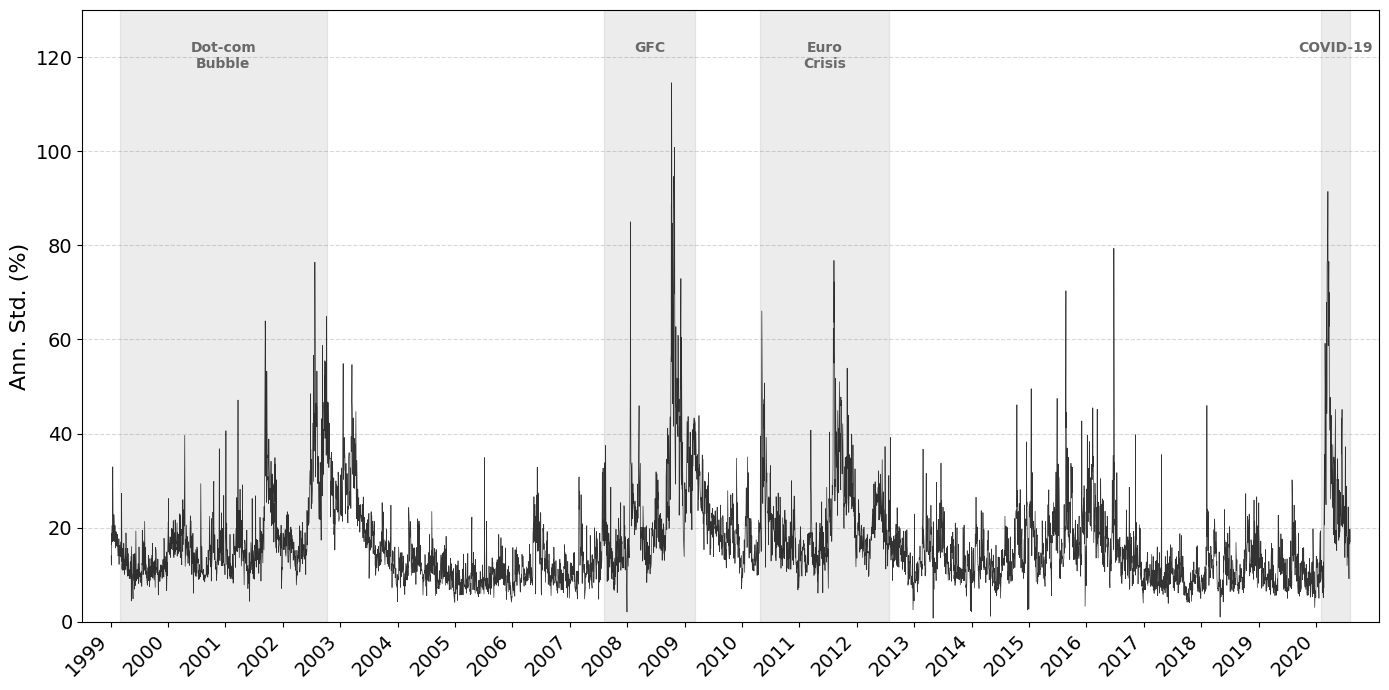

In [225]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 7))

# Convert RVD to annualized volatility for plotting
rv_ann = np.sqrt(MALL["RVD"] * 252) * 100

# Plot RVD
ax.plot(MALL.index, rv_ann, color="black", linewidth=0.5, alpha=0.8)
ax.set_ylabel("Ann. Std. (%)", fontsize=16)

# Set y-axis limit to 130
ax.set_ylim(0, 130)

# Symmetric padding
start_data = pd.Timestamp("1999-01-05")
end_data   = pd.Timestamp("2020-08-07")
padding    = pd.DateOffset(months=6)
ax.set_xlim(start_data - padding, end_data + padding)

# Format x-axis — only show ticks between 1999 and 2020 inclusive
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Remove 1998 and 2021 tick labels
ax.set_xticks([t for t in ax.get_xticks()
               if mdates.date2num(pd.Timestamp("1999-01-01")) <= t
               <= mdates.date2num(pd.Timestamp("2020-12-31"))])
plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(fontsize=14)

# Add shaded regions for major crisis periods
crisis_periods = [
    ("1999-03-01", "2002-10-09", "Dot-com\nBubble"),
    ("2007-08-09", "2009-03-09", "GFC"),
    ("2010-04-27", "2012-07-26", "Euro\nCrisis"),
    ("2020-02-01", "2020-08-07", "COVID-19"),
]

for start, end, label in crisis_periods:
    ax.axvspan(
        pd.Timestamp(start),
        pd.Timestamp(end),
        alpha=0.15,
        color="gray"
    )
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(
        mid, ax.get_ylim()[1] * 0.95,
        label,
        fontsize=10,
        ha="center",
        va="top",
        color="dimgray",
        fontweight="bold"
    )

ax.grid(True, linestyle="--", alpha=0.3, color="gray", axis="y")
ax.set_axisbelow(True)
ax.set_facecolor("white")

plt.tight_layout()
plt.savefig(
    "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Figures/Data/RV_time_series.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

#### Box-plot

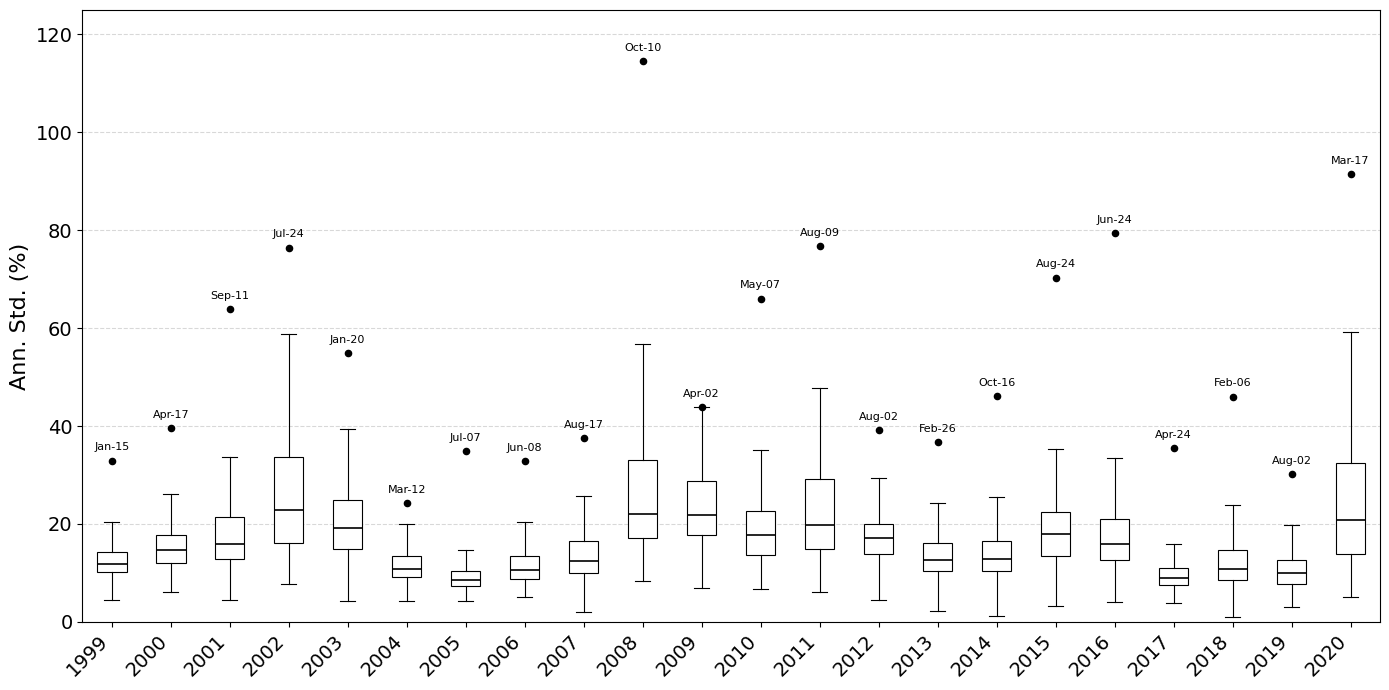

In [228]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prepare data
rv_ann = np.sqrt(MALL["RVD"] * 252) * 100
rv_ann_df = pd.DataFrame({
    "RVD_ann": rv_ann,
    "Year":    MALL.index.year,
    "Date":    MALL.index
})

# Group by year
years = sorted(rv_ann_df["Year"].unique())
data_by_year = [rv_ann_df[rv_ann_df["Year"] == y]["RVD_ann"].values for y in years]

# Find maximum value and corresponding date for each year
yearly_max_idx  = rv_ann_df.groupby("Year")["RVD_ann"].idxmax()
yearly_max_val  = rv_ann_df.loc[yearly_max_idx, "RVD_ann"]
yearly_max_date = rv_ann_df.loc[yearly_max_idx, "Date"]

fig, ax = plt.subplots(figsize=(14, 7))

# Plot boxplot without any fliers
bp = ax.boxplot(
    data_by_year,
    positions=range(len(years)),
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="white", color="black", linewidth=0.8),
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=0.8),
    capprops=dict(color="black", linewidth=0.8),
)

# Fixed offset for text above dot in data coordinates
y_range      = rv_ann_df["RVD_ann"].max() - rv_ann_df["RVD_ann"].min()
fixed_offset = y_range * 0.015

# Mark maximum outlier for each year with date label centered above dot
for i, year in enumerate(years):
    max_val      = yearly_max_val[yearly_max_val.index == yearly_max_idx[year]].values[0]
    max_date     = yearly_max_date[yearly_max_date.index == yearly_max_idx[year]].values[0]
    max_date_str = pd.Timestamp(max_date).strftime("%b-%d")
    ax.scatter(i, max_val, color="black", s=20, zorder=5, marker="o")
    ax.text(
        i, max_val + fixed_offset, max_date_str,
        fontsize=8, ha="center", va="bottom", color="black", rotation=0
    )

# Set y-axis limit to 125
ax.set_ylim(0, 125)

# X-axis formatting
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45, ha="right", fontsize=14)

# Labels — no title
ax.set_ylabel("Ann. Std. (%)", fontsize=16)
plt.yticks(fontsize=14)

ax.grid(True, linestyle="--", alpha=0.3, color="gray", axis="y")
ax.set_axisbelow(True)
ax.set_facecolor("white")

plt.tight_layout()
plt.savefig(
    "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Figures/Data/RV_box_plot.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

In [170]:
MALL.columns

Index(['RVD', 'RVW', 'RVM', 'logRVD', 'logRVW', 'logRVM', 'RVD_pos', 'RVD_neg',
       'RD_neg', 'RW_neg', 'RM_neg', 'RQ', 'VSTOXX', 'logVSTOXX', 'EPU',
       'logEPU', 'EPU_1m_lag', 'logEPU_1m_lag', 'EURUSD', 'EURUSD_ret', 'CISS',
       'BRENT', 'BRENT_ret', 'NIKKEI_ret', 'NIKKEI_sq', 'SP500_ret_lag',
       'SP500_sq_lag', 'M1W', 'M1M', 'RV_target', 'logRV_target'],
      dtype='object')

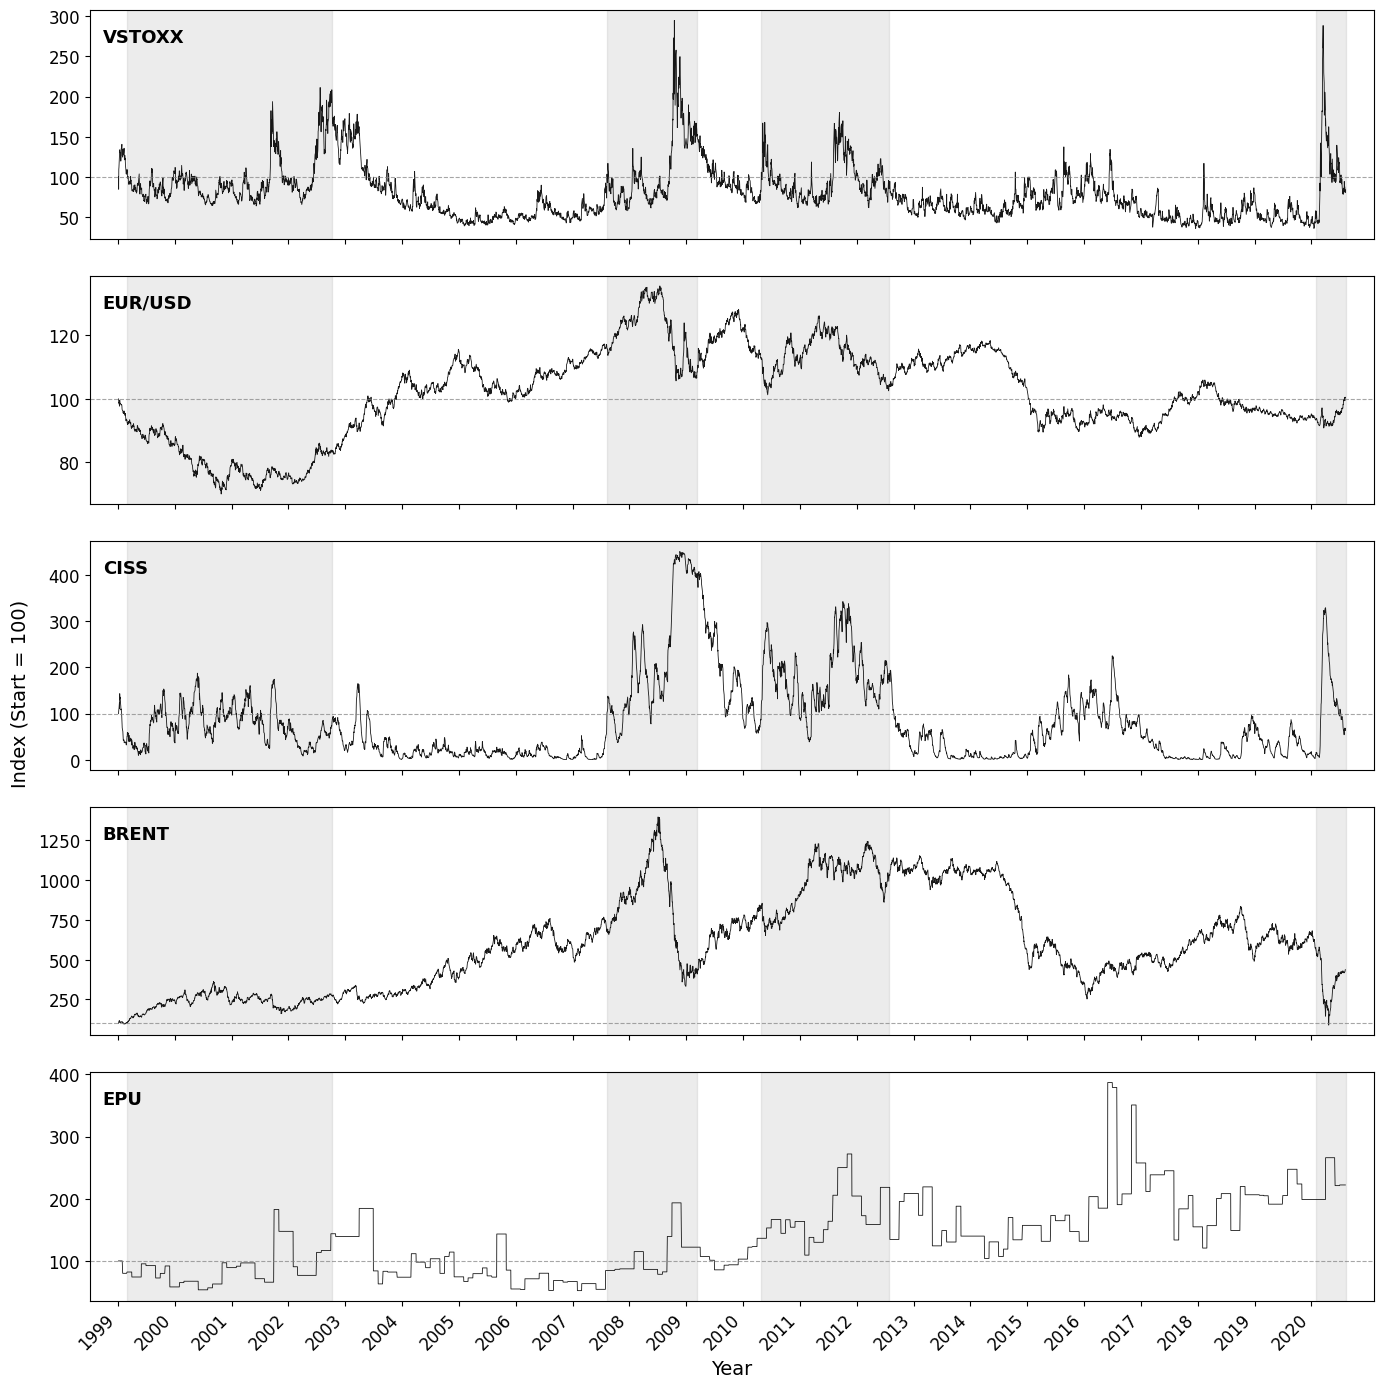

In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================================================
# 0. Reset to default matplotlib style
# =========================================================
plt.rcdefaults()
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]

# =========================================================
# 1. Data preparation
# =========================================================
cols = ["VSTOXX", "EURUSD", "CISS", "BRENT", "EPU"]

df_plot = MALL[cols].copy()
df_plot.index = pd.to_datetime(df_plot.index)
df_plot = df_plot.sort_index().dropna()

# Normalize to index = 100
df_indexed = df_plot.div(df_plot.iloc[0]).mul(100)

# =========================================================
# 2. Crisis periods (shading only)
# =========================================================
crisis_periods = [
    ("1999-03-01", "2002-10-09"),
    ("2007-08-09", "2009-03-09"),
    ("2010-04-27", "2012-07-26"),
    ("2020-02-01", "2020-08-07"),
]

# =========================================================
# 3. Plot setup (NOW 5 PANELS)
# =========================================================
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

series_names = ["VSTOXX", "EURUSD", "CISS", "BRENT", "EPU"]
panel_labels = ["VSTOXX", "EUR/USD", "CISS", "BRENT", "EPU"]

start_data = df_indexed.index.min()
end_data   = df_indexed.index.max()
padding    = pd.DateOffset(months=6)

# =========================================================
# 4. Plot each panel
# =========================================================
for ax, col, label in zip(axes, series_names, panel_labels):
    
    ax.plot(
        df_indexed.index,
        df_indexed[col],
        color="black",
        linewidth=0.6,
        alpha=0.9
    )
    
    # Reference line at 100
    ax.axhline(
        100,
        color="gray",
        linestyle="--",
        linewidth=0.8,
        alpha=0.7
    )
    
    # Crisis shading
    for start, end in crisis_periods:
        ax.axvspan(
            pd.Timestamp(start),
            pd.Timestamp(end),
            color="gray",
            alpha=0.15
        )
    
    # Box around subplot
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
    
    # No grid
    ax.grid(False)
    
    # Panel label
    ax.text(
        0.01, 0.92,
        label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        ha="left",
        va="top"
    )
    
    # Ticks
    ax.tick_params(axis="y", labelsize=12)
    ax.tick_params(axis="x", labelsize=12)
    
    # Symmetric padding
    ax.set_xlim(start_data - padding, end_data + padding)

# =========================================================
# 5. X-axis formatting
# =========================================================
axes[-1].xaxis.set_major_locator(mdates.YearLocator(1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

valid_ticks = [
    t for t in axes[-1].get_xticks()
    if mdates.date2num(pd.Timestamp(f"{start_data.year}-01-01")) <= t
    <= mdates.date2num(pd.Timestamp(f"{end_data.year}-12-31"))
]
axes[-1].set_xticks(valid_ticks)

plt.setp(axes[-1].get_xticklabels(), rotation=45, ha="right", fontsize=12)

# Hide x labels on upper panels
for ax in axes[:-1]:
    ax.tick_params(axis="x", labelbottom=False)

# =========================================================
# 6. Labels and layout
# =========================================================
fig.supylabel(
    "Index (Start = 100)",
    fontsize=14,
    x=0.015
)

axes[-1].set_xlabel("Year", fontsize=14)

plt.tight_layout()
fig.subplots_adjust(hspace=0.16)

# =========================================================
# 7. Save
# =========================================================
plt.savefig(
    "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Figures/Data/macro_panels_with_EPU.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

## 2.0 Save MALL.csv 

In [175]:
# Save updated MALL with target variable included
folder_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data"
file_path = os.path.join(folder_path, "MALL.csv")
MALL.to_csv(file_path, index=True)
print(f"\nFile saved successfully at: {file_path}")


File saved successfully at: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/MALL.csv
